In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
a = np.array([23, 21, 19, 24, 35, 17, 18, 24, 33, 27, 21, 23])
b = np.array([31, 28, 19, 24, 32, 27, 16, 41, 23, 32, 29, 33])

In [3]:
print(f"mean of a: {np.mean(a)}")
print(f"mean of b: {np.mean(b)}")

mean of a: 23.75
mean of b: 27.916666666666668


In [5]:
d = b.mean() - a.mean()
print(f"d: {d}")

d: 4.166666666666668


In [6]:
np.ones(len(b))

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [7]:
np.append(np.zeros(len(a)),np.ones(len(b)))

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1.])

In [9]:
sales = np.array([
    np.append(np.zeros(len(a)),np.ones(len(b))),
    np.append(a,b)
])
sales

array([[ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,
         1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.],
       [23., 21., 19., 24., 35., 17., 18., 24., 33., 27., 21., 23., 31.,
        28., 19., 24., 32., 27., 16., 41., 23., 32., 29., 33.]])

In [12]:
sales_T = sales.T
sales_T

array([[ 0., 23.],
       [ 0., 21.],
       [ 0., 19.],
       [ 0., 24.],
       [ 0., 35.],
       [ 0., 17.],
       [ 0., 18.],
       [ 0., 24.],
       [ 0., 33.],
       [ 0., 27.],
       [ 0., 21.],
       [ 0., 23.],
       [ 1., 31.],
       [ 1., 28.],
       [ 1., 19.],
       [ 1., 24.],
       [ 1., 32.],
       [ 1., 27.],
       [ 1., 16.],
       [ 1., 41.],
       [ 1., 23.],
       [ 1., 32.],
       [ 1., 29.],
       [ 1., 33.]])

In [13]:
print(f"Sales Shape: {sales.shape}")
print(f"Sales_T Shape: {sales_T.shape}")

Sales Shape: (2, 24)
Sales_T Shape: (24, 2)


In [14]:
np.random.shuffle(sales_T)

In [15]:
sales_T

array([[ 0., 21.],
       [ 0., 27.],
       [ 1., 32.],
       [ 0., 35.],
       [ 0., 24.],
       [ 0., 23.],
       [ 0., 18.],
       [ 1., 41.],
       [ 0., 21.],
       [ 1., 32.],
       [ 0., 17.],
       [ 1., 28.],
       [ 1., 31.],
       [ 1., 33.],
       [ 1., 16.],
       [ 1., 19.],
       [ 1., 24.],
       [ 0., 19.],
       [ 1., 27.],
       [ 1., 23.],
       [ 1., 29.],
       [ 0., 23.],
       [ 0., 24.],
       [ 0., 33.]])

In [19]:
experiment_label = np.random.randint(0, 2, len(sales_T))
experiment_label

array([0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1,
       1, 0])

In [22]:
experiment_data = np.array([
    experiment_label,
    sales_T[:, 1]
])
experiment_data_T = experiment_data.T
experiment_data_T

array([[ 0., 21.],
       [ 0., 27.],
       [ 1., 32.],
       [ 1., 35.],
       [ 0., 24.],
       [ 1., 23.],
       [ 1., 18.],
       [ 0., 41.],
       [ 0., 21.],
       [ 1., 32.],
       [ 0., 17.],
       [ 1., 28.],
       [ 1., 31.],
       [ 0., 33.],
       [ 1., 16.],
       [ 0., 19.],
       [ 0., 24.],
       [ 1., 19.],
       [ 1., 27.],
       [ 0., 23.],
       [ 1., 29.],
       [ 1., 23.],
       [ 1., 24.],
       [ 0., 33.]])

In [28]:
ex0 = experiment_data_T[experiment_data_T[:, 0] == 0][:, 1].mean()
ex1 = experiment_data_T[experiment_data_T[:, 0] == 1][:, 1].mean()

print(f"Mean of data_label is 0: {ex0}")
print(f"Mean of data_label is 1: {ex1}")

Mean of data_label is 0: 25.727272727272727
Mean of data_label is 1: 25.923076923076923


In [40]:
def sh_exp(N):
  experiment_diff_mean = np.empty([N, 1])

  for times in np.arange(N):
    experiment_label = np.random.randint(0, 2, len(sales_T))
    experiment_data = np.array([
        experiment_label,
        sales_T[:, 1]
    ]).T
    experiment_diff_mean[times] = experiment_data[experiment_data[:, 0] == 1][:, 1].mean() - experiment_data[experiment_data[:, 0] == 0][:, 1].mean()
  return experiment_diff_mean

In [41]:
diff_arr = sh_exp(1000)

In [48]:
print(f"The number of values greater than {d}: {len(diff_arr[diff_arr >= d])}")
print(f"The probability of being greater than {d}: {len(diff_arr[diff_arr >= d])/1000 * 100}")

The number of values greater than 4.166666666666668: 74
The probability of being greater than 4.166666666666668: 7.3999999999999995


/tmp/ipython-input-4001154591.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(diff_arr, kde= False)


<Axes: >

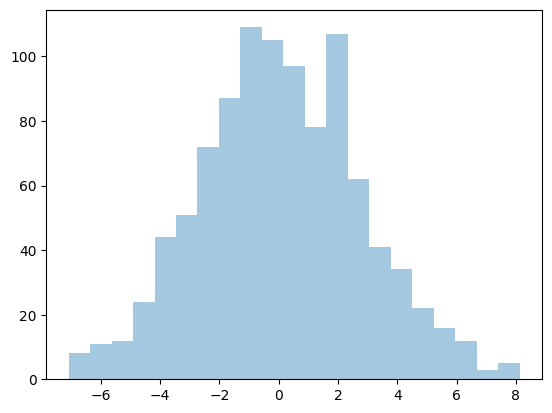

In [49]:
sns.distplot(diff_arr, kde= False)